# Laboratorio 07 - Punto 3: aprendizaje semisupervisado y activo

Estudiante: Arduz Espada Juan Sebastian

Materia: SIS 420 - Inteligencia Artificial I

Dataset: **Sign Language MNIST** (Kaggle): https://www.kaggle.com/datasets/datamunge/sign-language-mnist

Lo que pide el punto:
- Buscar un dataset de imagenes o audio sin etiquetas, con n mayor a 10 y m mayor a 10.000, coordinado para que no se repita con otro companiero.
- Aplicar aprendizaje semisupervisado.
- Aplicar aprendizaje activo.

El dataset tiene 27.455 imagenes de 28x28 (m = 27.455 y n = 784) de letras del alfabeto de senias americano. **Trabajo como si no tuviera etiquetas**: el agrupamiento y la eleccion de que imagenes etiquetar se hacen sin mirarlas. Las etiquetas reales las uso solo para dos cosas: para medir que tan bien salio todo, y para hacer de "persona que etiqueta" cuando el modelo pide una etiqueta, que es justamente la idea del aprendizaje activo.

## 1. Librerias y carga del dataset

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from skimage.feature import hog
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score, accuracy_score

SEMILLA = 42
np.random.seed(SEMILLA)

ruta = kagglehub.dataset_download('datamunge/sign-language-mnist')
entrenamiento = pd.read_csv(ruta + '/sign_mnist_train.csv')
prueba = pd.read_csv(ruta + '/sign_mnist_test.csv')

# las etiquetas se guardan aparte: el trabajo no supervisado no las usa
y_pool = entrenamiento['label'].values
X_pool = entrenamiento.drop(columns=['label']).values.astype(np.float32) / 255.0
y_prueba = prueba['label'].values
X_prueba = prueba.drop(columns=['label']).values.astype(np.float32) / 255.0

CLASES = np.unique(y_pool)
LETRAS = {i: chr(ord('A') + i) for i in range(26)}        # 0 = A, 1 = B, ... (no estan la J ni la Z)

print('Imagenes para trabajar (m):', X_pool.shape[0], '  Caracteristicas (n):', X_pool.shape[1])
print('Imagenes de prueba:', X_prueba.shape[0])
print('Clases distintas:', len(CLASES), '->', ''.join(LETRAS[c] for c in CLASES))
print('Cumple m mayor a 10000:', X_pool.shape[0] > 10000, ' | Cumple n mayor a 10:', X_pool.shape[1] > 10)

Imagenes para trabajar (m): 27455   Caracteristicas (n): 784
Imagenes de prueba: 7172
Clases distintas: 24 -> ABCDEFGHIKLMNOPQRSTUVWXY
Cumple m mayor a 10000: True  | Cumple n mayor a 10: True


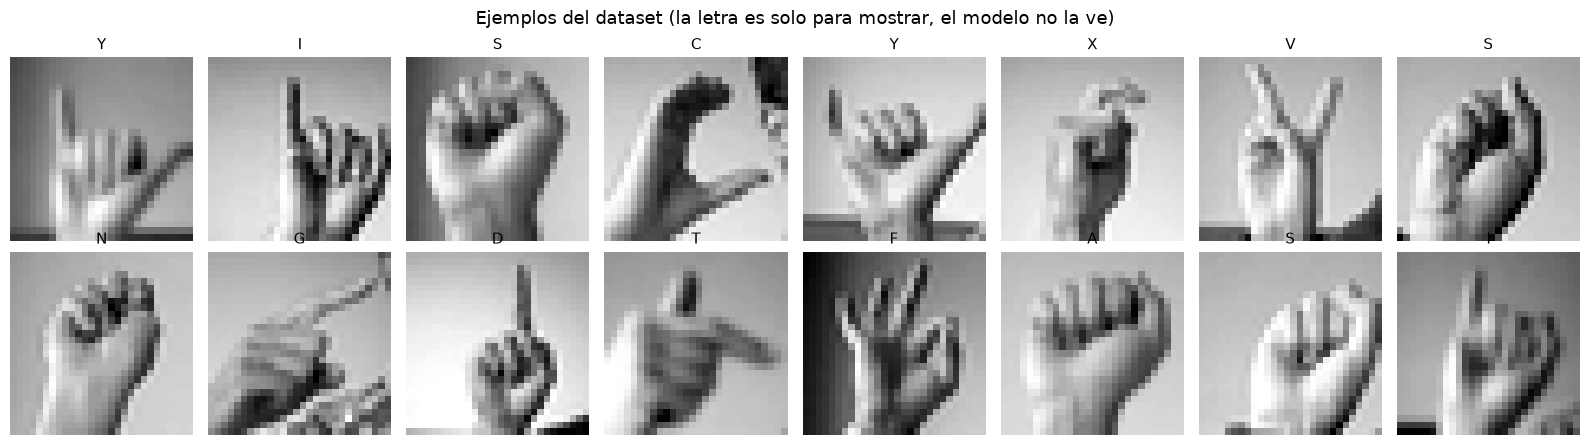

In [2]:
fig, ejes = plt.subplots(2, 8, figsize=(16, 4.5))
indices_muestra = np.random.RandomState(SEMILLA).choice(len(X_pool), 16, replace=False)
for ax, i in zip(ejes.flat, indices_muestra):
    ax.imshow(X_pool[i].reshape(28, 28), cmap='gray')
    ax.set_title(LETRAS[y_pool[i]], fontsize=11)
    ax.axis('off')
plt.suptitle('Ejemplos del dataset (la letra es solo para mostrar, el modelo no la ve)', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Preprocesado: de la imagen a numeros utiles

Primero divido los pixeles entre 255 para que queden entre 0 y 1. Despues probe dos formas de representar cada imagen:

- **Pixeles directos:** los 784 valores tal cual.
- **HOG (histograma de gradientes orientados):** en vez de mirar el brillo de cada pixel, mide en cada pedacito de la imagen hacia donde apuntan los bordes. En una mano eso describe la forma de los dedos y no cambia tanto si la foto salio mas clara o mas oscura.

En los dos casos aplico **PCA** para bajar a 50 caracteristicas. PCA se queda con las direcciones donde los datos mas varian. Lo uso porque KMeans trabaja con distancias y, con cientos de dimensiones, las distancias dejan de distinguir bien; ademas todo corre mucho mas rapido.

In [3]:
def extraer_hog(X):
    """Convierte cada imagen de 28x28 en su descriptor HOG (direccion de los bordes por pedacito)."""
    return np.array([hog(imagen.reshape(28, 28), orientations=9, pixels_per_cell=(7, 7),
                         cells_per_block=(2, 2)) for imagen in X])


inicio = time.time()
H_pool, H_prueba = extraer_hog(X_pool), extraer_hog(X_prueba)
print('HOG:', X_pool.shape[1], 'pixeles ->', H_pool.shape[1], 'valores   (', round(time.time() - inicio), 's )')


def reducir_con_pca(A, B):
    """Ajusta PCA con los datos de trabajo y transforma los dos conjuntos."""
    modelo_pca = PCA(n_components=50, random_state=SEMILLA).fit(A)
    return modelo_pca.transform(A), modelo_pca.transform(B), modelo_pca


Zpix_pool, Zpix_prueba, pca_pixeles = reducir_con_pca(X_pool, X_prueba)
Z_pool, Z_prueba, pca_hog = reducir_con_pca(H_pool, H_prueba)
print('Varianza explicada por PCA sobre pixeles:', round(pca_pixeles.explained_variance_ratio_.sum() * 100, 1), '%')
print('Varianza explicada por PCA sobre HOG:    ', round(pca_hog.explained_variance_ratio_.sum() * 100, 1), '%')

HOG: 784 pixeles -> 324 valores   ( 10 s )


Varianza explicada por PCA sobre pixeles: 88.7 %
Varianza explicada por PCA sobre HOG:     80.0 %


### Cual de las dos representaciones conviene

Las comparo con dos medidas: que exactitud alcanza un clasificador si tuviera todas las etiquetas, y que tan puros salen los clusters de KMeans (cuanto se parecen los grupos a las letras reales).

In [4]:
filas = []
for nombre, Za, Zb in [('pixeles + PCA', Zpix_pool, Zpix_prueba), ('HOG + PCA', Z_pool, Z_prueba)]:
    modelo = LogisticRegression(max_iter=2000, random_state=SEMILLA).fit(Za, y_pool)
    exactitud = accuracy_score(y_prueba, modelo.predict(Zb))
    agrupamiento = KMeans(n_clusters=len(CLASES), n_init=10, random_state=SEMILLA).fit(Za)
    conteo = pd.crosstab(agrupamiento.labels_, y_pool)
    pureza = conteo.max(axis=1).sum() / conteo.sum().sum()
    filas.append({'caracteristicas': nombre, 'exactitud con todas las etiquetas': round(exactitud, 4),
                  'pureza de los clusters': round(pureza, 4)})
pd.DataFrame(filas).set_index('caracteristicas')

,exactitud con todas las etiquetas,pureza de los clusters
caracteristicas,,
pixeles + PCA,0.690,0.2017
HOG + PCA,0.837,0.4865


Con HOG el clasificador pasa de 0.690 a 0.837 de exactitud, y la pureza de los clusters sube de 0.20 a 0.49. Tiene sentido: los pixeles sueltos dependen del brillo de la foto y de donde quedo la mano, mientras que HOG mira la forma de los bordes, que es lo que diferencia una letra de otra.

Me quedo con HOG + PCA para todo lo que sigue.

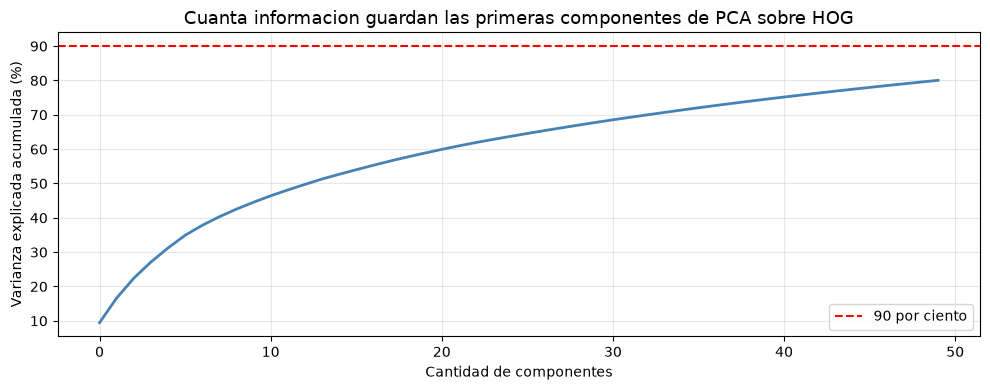

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca_hog.explained_variance_ratio_) * 100, linewidth=2, color='steelblue')
plt.axhline(90, color='red', linestyle='--', label='90 por ciento')
plt.title('Cuanta informacion guardan las primeras componentes de PCA sobre HOG', fontsize=13)
plt.xlabel('Cantidad de componentes')
plt.ylabel('Varianza explicada acumulada (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Aprendizaje no supervisado: KMeans

Agrupo las 27.455 imagenes sin usar ninguna etiqueta. Pruebo varios valores de k con el metodo del codo y con el silhouette. El silhouette lo calculo sobre una muestra de 5.000 imagenes porque con todas es muy lento.

k =   5   inercia =       51,485   silhouette = 0.0818


k =  10   inercia =       45,976   silhouette = 0.0868


k =  15   inercia =       42,215   silhouette = 0.0935


k =  20   inercia =       40,118   silhouette = 0.0960


k =  24   inercia =       38,634   silhouette = 0.1033


k =  30   inercia =       36,877   silhouette = 0.1056


k =  40   inercia =       34,698   silhouette = 0.1104


k =  50   inercia =       33,022   silhouette = 0.1166
Tiempo: 11 s


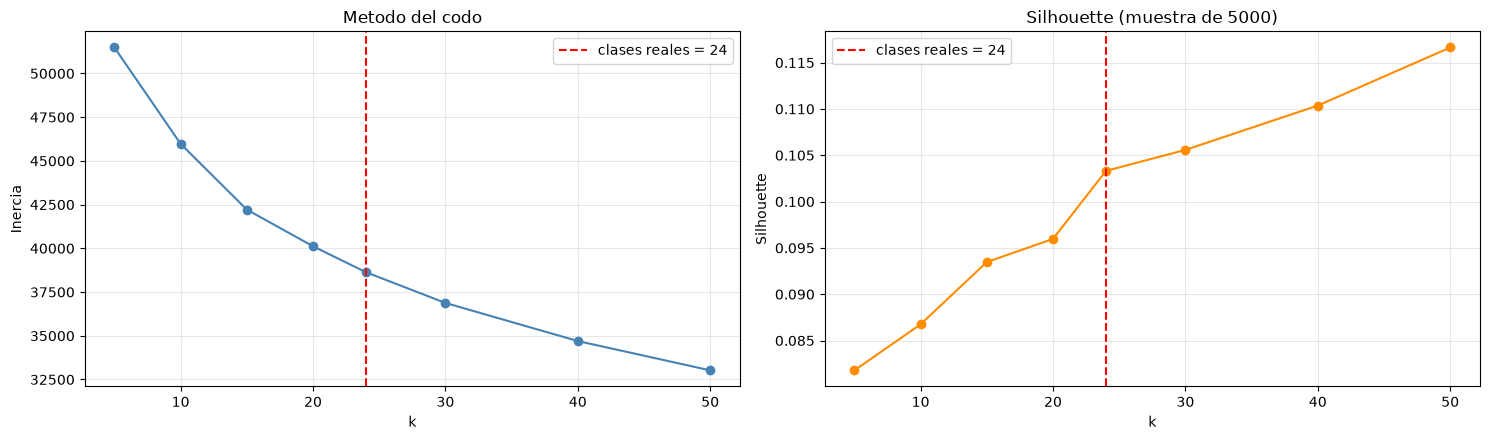

In [6]:
ks = [5, 10, 15, 20, 24, 30, 40, 50]
inercias, silhouettes = [], []
muestra = np.random.RandomState(SEMILLA).choice(len(Z_pool), 5000, replace=False)

inicio = time.time()
for k in ks:
    modelo = KMeans(n_clusters=k, n_init=5, random_state=SEMILLA).fit(Z_pool)
    inercias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(Z_pool[muestra], modelo.labels_[muestra]))
    print(f'k = {k:3d}   inercia = {modelo.inertia_:12,.0f}   silhouette = {silhouettes[-1]:.4f}')
print('Tiempo:', round(time.time() - inicio), 's')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
ax1.plot(ks, inercias, marker='o', color='steelblue')
ax1.axvline(len(CLASES), color='red', linestyle='--', label=f'clases reales = {len(CLASES)}')
ax1.set_title('Metodo del codo')
ax1.set_xlabel('k')
ax1.set_ylabel('Inercia')
ax2.plot(ks, silhouettes, marker='o', color='darkorange')
ax2.axvline(len(CLASES), color='red', linestyle='--', label=f'clases reales = {len(CLASES)}')
ax2.set_title('Silhouette (muestra de 5000)')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette')
for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Imagenes por cluster: [1830  515 1025 1612 1476  964 2326 1212  937 1185  973 1250  250  565
 1013 1824  769 2936  768 1207  722  768  447  881]


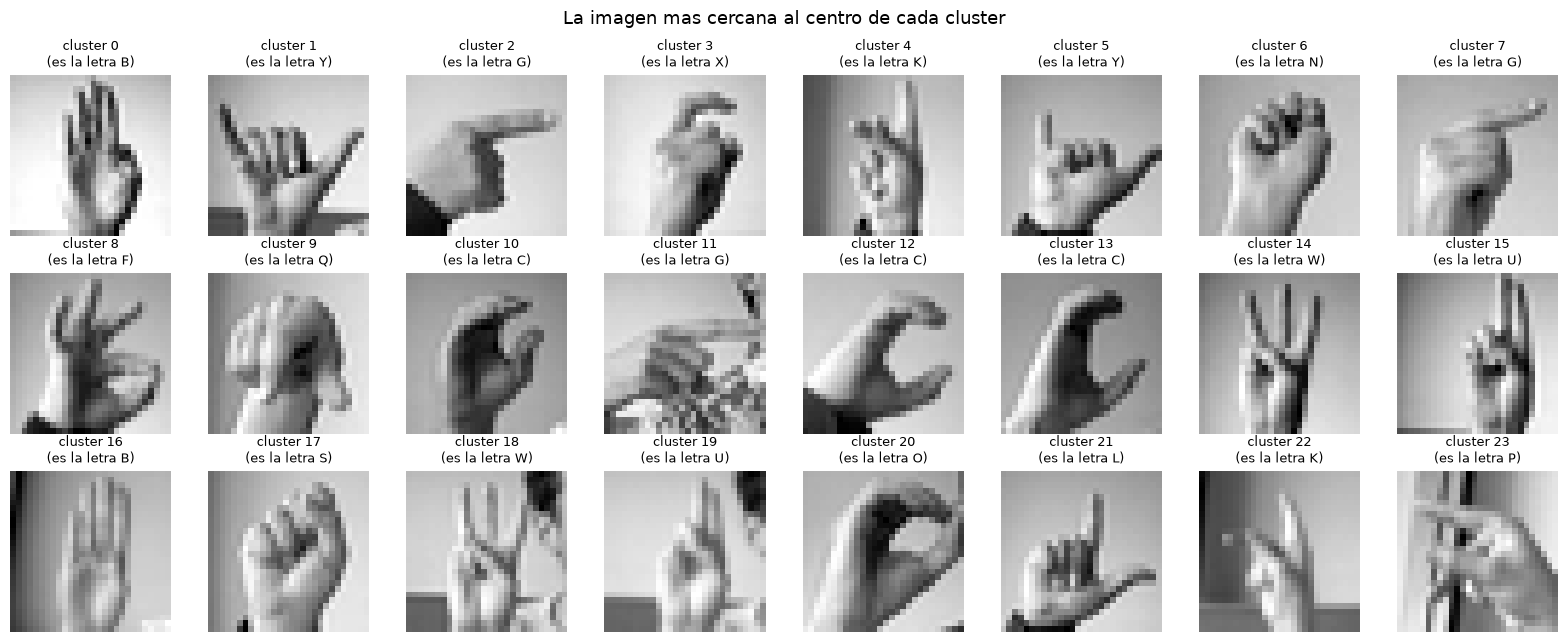

In [7]:
K_CLUSTERS = 24                                   # uso la misma cantidad que letras tiene el dataset
kmeans = KMeans(n_clusters=K_CLUSTERS, n_init=10, random_state=SEMILLA).fit(Z_pool)
clusters = kmeans.labels_
print('Imagenes por cluster:', np.bincount(clusters))

# imagen mas cercana al centro de cada cluster: es la mas representativa del grupo
distancias_al_centro = kmeans.transform(Z_pool)
representantes = np.array([np.where(clusters == c)[0][np.argmin(distancias_al_centro[clusters == c, c])]
                           for c in range(K_CLUSTERS)])

fig, ejes = plt.subplots(3, 8, figsize=(16, 6.5))
for c, ax in enumerate(ejes.flat):
    ax.imshow(X_pool[representantes[c]].reshape(28, 28), cmap='gray')
    ax.set_title(f'cluster {c}\n(es la letra {LETRAS[y_pool[representantes[c]]]})', fontsize=9)
    ax.axis('off')
plt.suptitle('La imagen mas cercana al centro de cada cluster', fontsize=13)
plt.tight_layout()
plt.show()

El silhouette da bajo (alrededor de 0.10) y no marca un k claro: sube de a poco mientras mas clusters pongo. Eso pasa porque las letras no forman bolas separadas como los datos inventados de los puntos 1 y 2, sino una nube continua donde las manos parecidas se mezclan.

Igual elijo k = 24, la cantidad de letras que tiene el dataset, porque es lo que necesito despues para el semisupervisado. En las imagenes de los representantes se ve que varios clusters agarraron una letra bien definida.

### Vista en 2 dimensiones

Dibujo las imagenes usando las 2 primeras componentes de PCA, pintadas por cluster y por letra real, para comparar que tan parecidos son los dos agrupamientos.

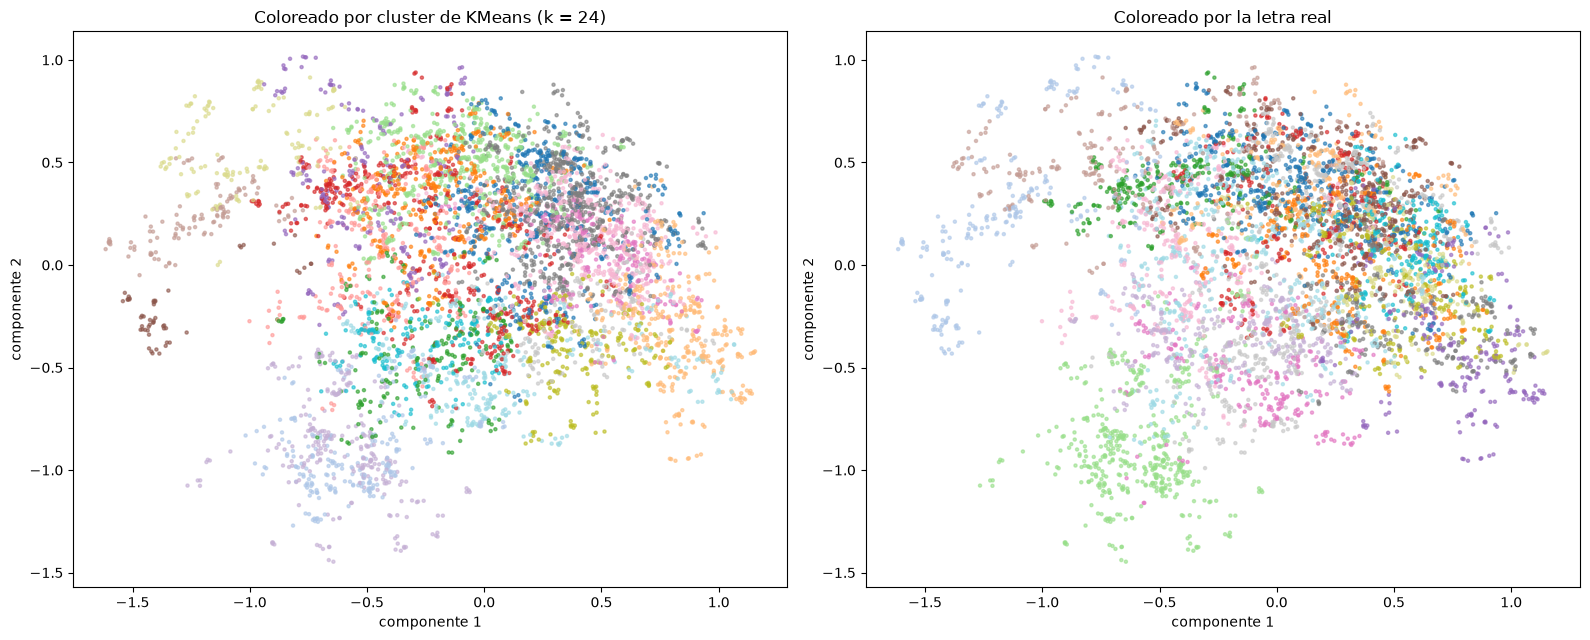

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
dibujo = np.random.RandomState(SEMILLA).choice(len(Z_pool), 6000, replace=False)
ax1.scatter(Z_pool[dibujo, 0], Z_pool[dibujo, 1], c=clusters[dibujo], cmap='tab20', s=5, alpha=0.6)
ax1.set_title(f'Coloreado por cluster de KMeans (k = {K_CLUSTERS})')
ax2.scatter(Z_pool[dibujo, 0], Z_pool[dibujo, 1], c=y_pool[dibujo], cmap='tab20', s=5, alpha=0.6)
ax2.set_title('Coloreado por la letra real')
for ax in (ax1, ax2):
    ax.set_xlabel('componente 1')
    ax.set_ylabel('componente 2')
plt.tight_layout()
plt.show()

### Que tan puros son los clusters

Aca si uso las etiquetas, pero solo para evaluar. Para cada cluster miro cual es la letra que mas se repite adentro: eso se llama **pureza**.

In [9]:
contingencia = pd.crosstab(clusters, [LETRAS[c] for c in y_pool])
purezas = contingencia.max(axis=1) / contingencia.sum(axis=1)
pureza_total = contingencia.max(axis=1).sum() / contingencia.sum().sum()

print('Pureza total:', round(pureza_total, 4))
print('Cluster mas puro:', purezas.idxmax(), '->', round(purezas.max(), 4),
      '| Cluster menos puro:', purezas.idxmin(), '->', round(purezas.min(), 4))
pd.DataFrame({'letra mas comun': contingencia.idxmax(axis=1),
              'imagenes del cluster': contingencia.sum(axis=1),
              'pureza': purezas.round(3)})

Pureza total: 0.4865
Cluster mas puro: 1 -> 1.0 | Cluster menos puro: 19 -> 0.2154


,letra mas comun,imagenes del cluster,pureza
row_0,,,
0,B,1830,0.286
1,Y,515,1.000
2,G,1025,0.584
3,X,1612,0.486
4,K,1476,0.331
5,Y,964,0.345
6,A,2326,0.362
7,T,1212,0.474
8,F,937,0.995


La pureza total es 0.49: si a cada cluster le pongo la letra que mas se repite adentro, acierto la mitad de las imagenes sin haber usado ni una etiqueta para agrupar.

Hay clusters casi perfectos (el 1 es 100% la letra Y, el 13 es 99.8% la C y el 8 es 99.5% la F) y otros muy mezclados (el 19 con 0.22). Tambien se ve que una misma letra aparece en varios clusters, por ejemplo la C y la Y, porque la senia cambia un poco segun quien la hace y como sale en la foto.

## 4. Aprendizaje semisupervisado

La idea es: etiquetar a mano cuesta caro, asi que **si solo puedo pagar 50 etiquetas, cuales conviene elegir**. Comparo cuatro formas, todas con el mismo presupuesto de 50 etiquetas, y mido la exactitud sobre el conjunto de prueba con una regresion logistica:

1. **Al azar:** 50 imagenes cualquiera.
2. **Representantes de KMeans:** agrupo en 50 clusters y etiqueto la imagen mas cercana al centro de cada uno. Asi las 50 imagenes son distintas entre si y cubren todo el dataset.
3. **Propagacion total:** despues de etiquetar los 50 representantes, le paso esa etiqueta a todas las imagenes de su cluster. De 50 etiquetas paso a 27.455 sin preguntarle nada a nadie.
4. **Propagacion parcial:** igual que la anterior pero solo al 30% de cada cluster que esta mas cerca del centro, que son las imagenes de las que estoy mas seguro.

In [10]:
PRESUPUESTO = 50


def entrenar_y_medir(indices_o_X, etiquetas, es_indice=True):
    """Entrena una regresion logistica y devuelve la exactitud en el conjunto de prueba."""
    X = Z_pool[indices_o_X] if es_indice else indices_o_X
    modelo = LogisticRegression(max_iter=2000, random_state=SEMILLA).fit(X, etiquetas)
    return accuracy_score(y_prueba, modelo.predict(Z_prueba))


rng = np.random.RandomState(SEMILLA)
resultados_semi = []

# 1. al azar
indices_azar = rng.choice(len(Z_pool), PRESUPUESTO, replace=False)
resultados_semi.append({'estrategia': f'{PRESUPUESTO} al azar',
                        'etiquetas humanas': PRESUPUESTO, 'imagenes de entrenamiento': PRESUPUESTO,
                        'exactitud': entrenar_y_medir(indices_azar, y_pool[indices_azar])})

# 2. representantes de KMeans
kmeans_rep = KMeans(n_clusters=PRESUPUESTO, n_init=10, random_state=SEMILLA).fit(Z_pool)
clusters_rep = kmeans_rep.labels_
distancias_rep = kmeans_rep.transform(Z_pool)
indices_rep = np.array([np.where(clusters_rep == c)[0][np.argmin(distancias_rep[clusters_rep == c, c])]
                        for c in range(PRESUPUESTO)])
resultados_semi.append({'estrategia': f'{PRESUPUESTO} representantes de KMeans',
                        'etiquetas humanas': PRESUPUESTO, 'imagenes de entrenamiento': PRESUPUESTO,
                        'exactitud': entrenar_y_medir(indices_rep, y_pool[indices_rep])})

# 3. propagacion total: cada imagen recibe la etiqueta del representante de su cluster
etiquetas_propagadas = y_pool[indices_rep][clusters_rep]
resultados_semi.append({'estrategia': 'propagacion total',
                        'etiquetas humanas': PRESUPUESTO, 'imagenes de entrenamiento': len(Z_pool),
                        'exactitud': entrenar_y_medir(np.arange(len(Z_pool)), etiquetas_propagadas)})

# 4. propagacion parcial: solo al 30% mas cercano al centro de cada cluster
PORCENTAJE = 0.30
seleccion = np.zeros(len(Z_pool), dtype=bool)
for c in range(PRESUPUESTO):
    del_cluster = np.where(clusters_rep == c)[0]
    corte = max(1, int(len(del_cluster) * PORCENTAJE))
    mas_cercanos = del_cluster[np.argsort(distancias_rep[del_cluster, c])][:corte]
    seleccion[mas_cercanos] = True
resultados_semi.append({'estrategia': f'propagacion parcial ({int(PORCENTAJE * 100)}% mas cercano)',
                        'etiquetas humanas': PRESUPUESTO, 'imagenes de entrenamiento': int(seleccion.sum()),
                        'exactitud': entrenar_y_medir(np.where(seleccion)[0], etiquetas_propagadas[seleccion])})

tabla_semi = pd.DataFrame(resultados_semi)
tabla_semi['exactitud'] = tabla_semi['exactitud'].round(4)

# referencia: cuanto se lograria etiquetando TODO el dataset
exactitud_todo = entrenar_y_medir(np.arange(len(Z_pool)), y_pool)
print('Referencia con las 27.455 etiquetas reales:', round(exactitud_todo, 4))
print('Que tan correctas son las etiquetas propagadas:',
      round(accuracy_score(y_pool, etiquetas_propagadas), 4))
tabla_semi

Referencia con las 27.455 etiquetas reales: 0.837
Que tan correctas son las etiquetas propagadas: 0.5499


,estrategia,etiquetas humanas,imagenes de entrenamiento,exactitud
0,50 al azar,50,50,0.2752
1,50 representantes de KMeans,50,50,0.3777
2,propagacion total,50,27455,0.4806
3,propagacion parcial (30% mas cercano),50,8214,0.4559


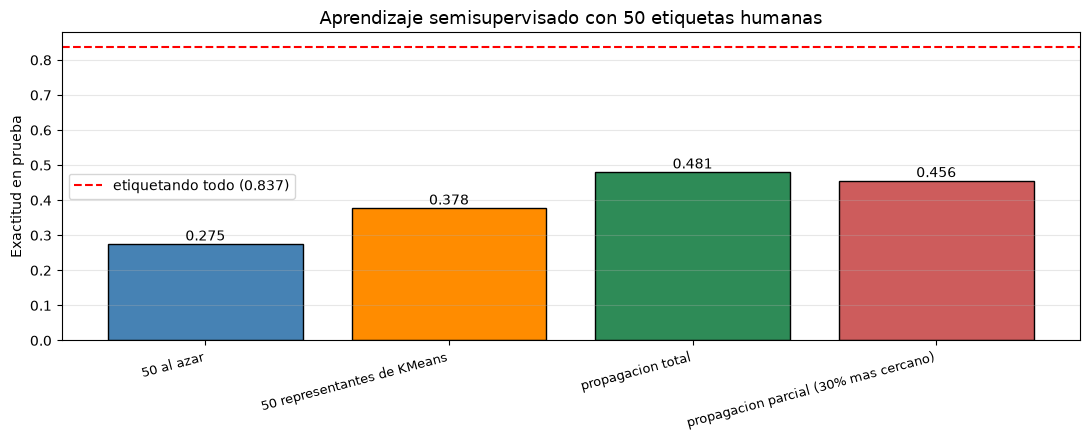

In [11]:
plt.figure(figsize=(11, 4.5))
colores = ['steelblue', 'darkorange', 'seagreen', 'indianred']
plt.bar(tabla_semi['estrategia'], tabla_semi['exactitud'], color=colores, edgecolor='black')
plt.axhline(exactitud_todo, color='red', linestyle='--',
            label=f'etiquetando todo ({exactitud_todo:.3f})')
for i, v in enumerate(tabla_semi['exactitud']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
plt.xticks(rotation=15, ha='right', fontsize=9)
plt.ylabel('Exactitud en prueba')
plt.title(f'Aprendizaje semisupervisado con {PRESUPUESTO} etiquetas humanas', fontsize=13)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Con las mismas 50 etiquetas, elegir cuales etiquetar cambia mucho el resultado:

| estrategia | exactitud |
|---|---|
| 50 al azar | 0.2752 |
| 50 representantes de KMeans | 0.3777 |
| propagacion total (50 -> 27.455) | 0.4806 |
| propagacion parcial (30% mas cercano) | 0.4559 |

Los representantes ganan 10 puntos sobre el azar porque, al tomar uno de cada cluster, las 50 imagenes son distintas entre si y cubren todo el dataset; eligiendo al azar pueden salir varias parecidas o faltar letras enteras.

La propagacion es la que mas sube (21 puntos sobre el azar). Lo interesante es que solo el 55% de las etiquetas propagadas son correctas, pero igual conviene: el modelo pasa de ver 50 ejemplos a ver 27.455, y eso compensa el ruido.

La propagacion parcial salio un poco peor que la total, que no era lo que esperaba. Al quedarme con el 30% mas cercano al centro las etiquetas son mas confiables, pero el modelo se queda con menos ejemplos y pierde variedad.

Como referencia, con las 27.455 etiquetas reales se llega a 0.837. O sea que con 50 etiquetas, que es el 0.18% del dataset, llego al 57% de ese resultado.

## 5. Aprendizaje activo

Aca el modelo elige que imagenes quiere que le etiqueten. Empiezo con 48 etiquetas y en cada ronda pido 48 mas, 10 rondas, hasta llegar a 528 etiquetas. Comparo dos formas de elegir:

- **Al azar:** se piden 48 imagenes cualquiera.
- **Por incertidumbre (margen):** el modelo predice todas las imagenes sin etiquetar y pide las 48 donde esta mas dudoso, o sea donde la diferencia entre la probabilidad de la primera opcion y la segunda es mas chica. Son las imagenes que estan justo en el borde entre dos letras.

Hago todo con 3 semillas distintas y promedio, porque si no el resultado depende mucho de con que imagenes se arranco. Las etiquetas las "pregunta" al dataset, que hace de persona que etiqueta.

In [12]:
INICIAL, POR_RONDA, RONDAS = 48, 48, 10


def aprendizaje_activo(estrategia, semilla):
    """Simula el ciclo: entrenar, pedir etiquetas, volver a entrenar."""
    rng_local = np.random.RandomState(semilla)
    etiquetados = list(rng_local.choice(len(Z_pool), INICIAL, replace=False))
    historial = []
    for ronda in range(RONDAS + 1):
        modelo = LogisticRegression(max_iter=2000, random_state=SEMILLA).fit(Z_pool[etiquetados], y_pool[etiquetados])
        historial.append({'etiquetas': len(etiquetados),
                          'exactitud': accuracy_score(y_prueba, modelo.predict(Z_prueba))})
        if ronda == RONDAS:
            break
        sin_etiquetar = np.setdiff1d(np.arange(len(Z_pool)), etiquetados)
        if estrategia == 'azar':
            nuevos = rng_local.choice(sin_etiquetar, POR_RONDA, replace=False)
        else:
            probabilidades = modelo.predict_proba(Z_pool[sin_etiquetar])
            ordenadas = np.sort(probabilidades, axis=1)
            margen = ordenadas[:, -1] - ordenadas[:, -2]      # mientras mas chico, mas dudoso
            nuevos = sin_etiquetar[np.argsort(margen)[:POR_RONDA]]
        etiquetados.extend(nuevos)
    return historial, modelo, etiquetados


inicio = time.time()
curvas = {}
for estrategia in ['azar', 'incertidumbre']:
    por_semilla = []
    for semilla in [1, 2, 3]:
        historial, modelo_final, etiquetados_final = aprendizaje_activo(estrategia, semilla)
        por_semilla.append([p['exactitud'] for p in historial])
        if semilla == 3 and estrategia == 'incertidumbre':
            modelo_incertidumbre, etiquetados_incertidumbre = modelo_final, etiquetados_final
    curvas[estrategia] = {'etiquetas': [p['etiquetas'] for p in historial],
                          'promedio': np.mean(por_semilla, axis=0),
                          'desviacion': np.std(por_semilla, axis=0)}
    print(f'{estrategia:15s} exactitud final = {curvas[estrategia]["promedio"][-1]:.4f} '
          f'(+- {curvas[estrategia]["desviacion"][-1]:.4f})')
print('Tiempo:', round(time.time() - inicio), 's')

azar            exactitud final = 0.6834 (+- 0.0164)


incertidumbre   exactitud final = 0.7334 (+- 0.0146)
Tiempo: 2 s


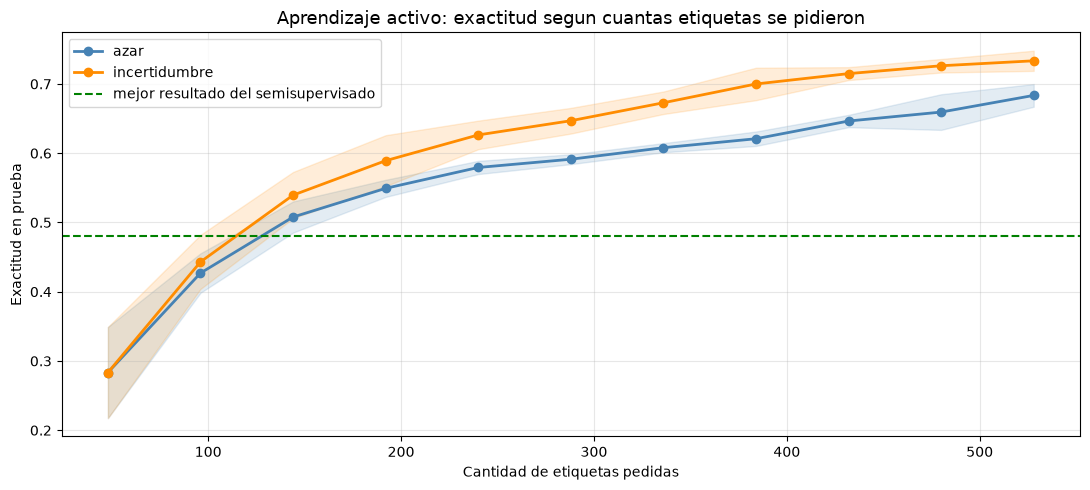

In [13]:
plt.figure(figsize=(11, 5))
for estrategia, color in [('azar', 'steelblue'), ('incertidumbre', 'darkorange')]:
    datos = curvas[estrategia]
    plt.plot(datos['etiquetas'], datos['promedio'], marker='o', color=color, linewidth=2, label=estrategia)
    plt.fill_between(datos['etiquetas'], datos['promedio'] - datos['desviacion'],
                     datos['promedio'] + datos['desviacion'], color=color, alpha=0.15)
plt.axhline(tabla_semi['exactitud'].max(), color='green', linestyle='--',
            label='mejor resultado del semisupervisado')
plt.title('Aprendizaje activo: exactitud segun cuantas etiquetas se pidieron', fontsize=13)
plt.xlabel('Cantidad de etiquetas pedidas')
plt.ylabel('Exactitud en prueba')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

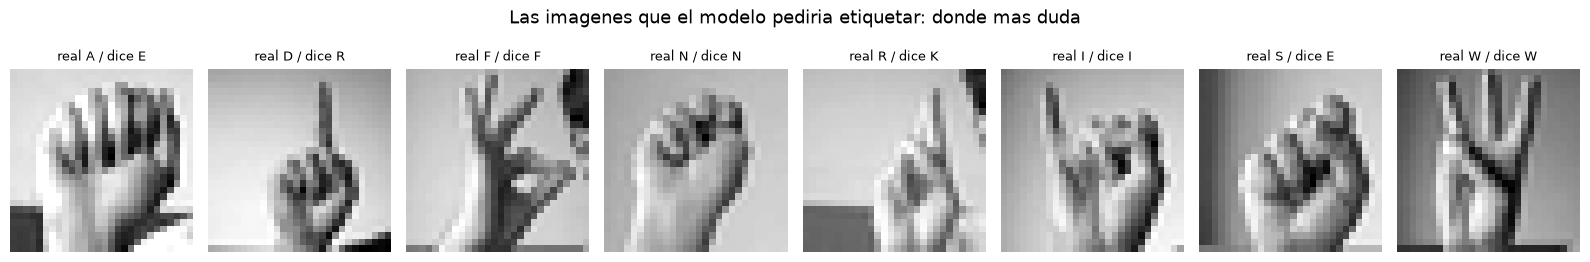

In [14]:
# las imagenes donde el modelo quedo mas dudoso en la ultima ronda
sin_etiquetar = np.setdiff1d(np.arange(len(Z_pool)), etiquetados_incertidumbre)
probabilidades = modelo_incertidumbre.predict_proba(Z_pool[sin_etiquetar])
ordenadas = np.sort(probabilidades, axis=1)
mas_dudosas = sin_etiquetar[np.argsort(ordenadas[:, -1] - ordenadas[:, -2])[:8]]
predichas = modelo_incertidumbre.predict(Z_pool[mas_dudosas])

fig, ejes = plt.subplots(1, 8, figsize=(16, 2.8))
for ax, i, p in zip(ejes, mas_dudosas, predichas):
    ax.imshow(X_pool[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'real {LETRAS[y_pool[i]]} / dice {LETRAS[p]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Las imagenes que el modelo pediria etiquetar: donde mas duda', fontsize=13)
plt.tight_layout()
plt.show()

Empezando con 48 etiquetas y pidiendo 48 por ronda, despues de 10 rondas (528 etiquetas) el aprendizaje activo llega a 0.7334 y pidiendo al azar llega a 0.6834: 5 puntos de diferencia con la misma cantidad de etiquetas. En la curva se ve que arrancan parejos y que la de incertidumbre se despega despues de las primeras rondas.

Funciona porque el modelo pide justo las imagenes donde duda entre dos letras, que son las que estan en el borde entre dos grupos. Una imagen que ya clasifica bien no le ensenia nada nuevo.

En las imagenes que pidio se ve que son senias dificiles, donde hasta a simple vista cuesta decidir que letra es.

Con 528 etiquetas, que es el 1.9% del dataset, llego a 0.7334, contra 0.837 que se logra etiquetando las 27.455.

## 6. Conclusiones

- El dataset cumple con lo pedido: 27.455 imagenes (m) y 784 caracteristicas (n). Lo trabaje sin usar las etiquetas ni para agrupar ni para elegir que etiquetar; las use solo para medir y para hacer de persona que etiqueta en el aprendizaje activo.
- Lo que mas cambio los resultados no fue el modelo sino como represento las imagenes: pasar de pixeles a HOG subio la exactitud de 0.690 a 0.837 y la pureza de los clusters de 0.20 a 0.49.
- Sin usar etiquetas, KMeans arma grupos que se parecen bastante a las letras (pureza 0.49) y varios clusters salen casi perfectos.
- Semisupervisado: con 50 etiquetas, elegirlas con KMeans y propagarlas al resto llega a 0.4806, contra 0.2752 de elegirlas al azar.
- Activo: pidiendo las imagenes donde el modelo duda se llega a 0.7334 contra 0.6834 pidiendo al azar, con las mismas 528 etiquetas.
- Las dos tecnicas sirven para lo mismo: cuando etiquetar cuesta caro, conviene pensar bien que se etiqueta en vez de etiquetar mas.